# Model #3 Tag-Visible Detector (Colab)

Run this notebook on Colab with a GPU runtime. It uses the fine-tuned Qwen LoRA adapter on Hugging Face to answer a simple zero-shot question: whether a clothing tag, label, or price tag is visible in the image.

Before running the full pass, put these large local data files in Google Drive, for example under `MyDrive/resell_copilot_data/`:

- `vinted_clothing_combined.parquet`
- `kleinanzeigen_clothing_combined.parquet`

The split JSON files are expected to come from the GitHub repo.

## 1. Check GPU

In [1]:
!nvidia-smi

Thu May  7 18:51:55 2026       
+-----------------------------------------------------------------------------------------+
| NVIDIA-SMI 580.82.07              Driver Version: 580.82.07      CUDA Version: 13.0     |
+-----------------------------------------+------------------------+----------------------+
| GPU  Name                 Persistence-M | Bus-Id          Disp.A | Volatile Uncorr. ECC |
| Fan  Temp   Perf          Pwr:Usage/Cap |           Memory-Usage | GPU-Util  Compute M. |
|                                         |                        |               MIG M. |
|=========================================+========================+======================|
|   0  Tesla T4                       Off |   00000000:00:04.0 Off |                    0 |
| N/A   43C    P8             13W /   70W |       0MiB /  15360MiB |      0%      Default |
|                                         |                        |                  N/A |
+-----------------------------------------+-----

## 2. Clone Repo

This assumes the latest Model #3 code has been pushed to GitHub. If `models/run_tag_detector.py` is missing after cloning, push the local repo changes first, then rerun this cell.

In [2]:
![ -d /content/Advanced_ML/.git ] || git clone https://github.com/mchlkan/Advanced_ML.git /content/Advanced_ML
%cd /content/Advanced_ML
!git pull --ff-only
!test -f models/run_tag_detector.py && echo 'Model #3 script found.' || echo 'ERROR: models/run_tag_detector.py is missing. Push the latest repo changes first.'

/content/Advanced_ML
Already up to date.
Model #3 script found.


## 3. Install Dependencies

`--load-in-4bit` needs `bitsandbytes`, and the adapter needs `peft`.

In [3]:
!pip -q install -U transformers accelerate peft bitsandbytes huggingface_hub tqdm
!pip -q install "pandas==2.2.2" "pillow<12" "pyarrow>=16"

   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 12.7/12.7 MB 76.0 MB/s eta 0:00:00
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 6.6/6.6 MB 78.4 MB/s eta 0:00:00


## 4. Hugging Face Login

You already accepted the model terms. Paste a Hugging Face access token when prompted. A read token is enough.

In [4]:
from huggingface_hub import login
login()

/usr/local/lib/python3.12/dist-packages/huggingface_hub/utils/_auth.py:93: UserWarning: 
The secret `HF_TOKEN` does not exist in your Colab secrets.
To authenticate with the Hugging Face Hub, create a token in your settings tab (https://huggingface.co/settings/tokens), set it as secret in your Google Colab and restart your session.
You will be able to reuse this secret in all of your notebooks.
Please note that authentication is recommended but still optional to access public models or datasets.
  warnings.warn(


## 5. Copy Data From Google Drive

Change `DATA_SOURCE_DIR` if your Drive folder is different.

In [7]:
from google.colab import drive
drive.mount('/content/drive')

DATA_SOURCE_DIR = '/content/drive/MyDrive/Resell_Copilot_data'

!mkdir -p data data/features
!cp "{DATA_SOURCE_DIR}/vinted_clothing_combined.parquet" data/vinted_clothing_combined.parquet
!cp "{DATA_SOURCE_DIR}/kleinanzeigen_clothing_combined.parquet" data/kleinanzeigen_clothing_combined.parquet
!ls -lh data/vinted_clothing_combined.parquet data/kleinanzeigen_clothing_combined.parquet data/splits/*.json

Drive already mounted at /content/drive; to attempt to forcibly remount, call drive.mount("/content/drive", force_remount=True).
-rw------- 1 root root 219M May  7 19:09 data/kleinanzeigen_clothing_combined.parquet
-rw-r--r-- 1 root root  29K May  7 18:50 data/splits/test_ids.json
-rw-r--r-- 1 root root 418K May  7 18:50 data/splits/train_ids.json
-rw-r--r-- 1 root root  47K May  7 18:50 data/splits/val_ids.json
-rw------- 1 root root 607M May  7 19:09 data/vinted_clothing_combined.parquet


## 6. Validate Data Shape

In [8]:
import json
import pandas as pd

vinted = pd.read_parquet('data/vinted_clothing_combined.parquet')
ka = pd.read_parquet('data/kleinanzeigen_clothing_combined.parquet')
print('vinted:', vinted.shape)
print('ka:', ka.shape)
for split in ['train', 'val', 'test']:
    ids = json.load(open(f'data/splits/{split}_ids.json'))
    print(split, len(ids))

vinted: (6409, 26)
ka: (2302, 26)
train 7390
val 821
test 500


## 7. Smoke Test On 10 Rows

This downloads the base model + adapter and runs only 10 examples. On a T4, model loading is the slow part.

In [12]:
%cd /content/Advanced_ML
!git pull --ff-only


/content/Advanced_ML
remote: Enumerating objects: 7, done.
remote: Counting objects: 100% (7/7), done.
remote: Compressing objects: 100% (1/1), done.
remote: Total 4 (delta 3), reused 4 (delta 3), pack-reused 0 (from 0)
Unpacking objects: 100% (4/4), 474 bytes | 94.00 KiB/s, done.
From https://github.com/mchlkan/Advanced_ML
   7acb752..2dd3c2b  main       -> origin/main
Updating 7acb752..2dd3c2b
Fast-forward
 models/run_tag_detector.py | 3 ++-
 1 file changed, 2 insertions(+), 1 deletion(-)


In [13]:
!python models/run_tag_detector.py \
  --model-id Qwen/Qwen3-VL-4B-Instruct \
  --adapter-id Rengo33/qwen3vl4b-resell-adapter \
  --load-in-4bit \
  --output /content/tag_visible_smoke.parquet \
  --limit 10 \
  --batch-size 1

Smoke-test limit active: 10 rows
Loading weights: 100% 713/713 [00:34<00:00, 20.69it/s]
Detecting visible tags: 100% 10/10 [02:28<00:00, 14.84s/it]
Saved tag-visible features: /content/tag_visible_smoke.parquet  rows=10
Parsed value counts:
tag_visible
0    9
1    1


## 8. Inspect Smoke Test

In [14]:
smoke = pd.read_parquet('/content/tag_visible_smoke.parquet')
smoke

,platform,id,split,tag_visible,raw_response
0,vinted,8758496421,train,0,no
1,vinted,8758496254,train,0,no
2,vinted,8758495839,test,1,yes
3,vinted,8758494444,train,0,no
4,vinted,8758494030,train,0,no
5,vinted,8758494238,train,0,no
6,vinted,8758232351,test,0,no
7,vinted,8758493927,train,0,no
8,vinted,8758394988,train,0,no
9,vinted,8758493768,train,0,no


/tmp/ipykernel_3770/78684002.py:52: UserWarning: Glyph 128149 (\N{TWO HEARTS}) missing from font(s) DejaVu Sans.
  plt.tight_layout()
/tmp/ipykernel_3770/78684002.py:52: UserWarning: Glyph 127800 (\N{CHERRY BLOSSOM}) missing from font(s) DejaVu Sans.
  plt.tight_layout()
/tmp/ipykernel_3770/78684002.py:52: UserWarning: Glyph 128076 (\N{OK HAND SIGN}) missing from font(s) DejaVu Sans.
  plt.tight_layout()
/usr/local/lib/python3.12/dist-packages/IPython/core/pylabtools.py:151: UserWarning: Glyph 128149 (\N{TWO HEARTS}) missing from font(s) DejaVu Sans.
  fig.canvas.print_figure(bytes_io, **kw)
/usr/local/lib/python3.12/dist-packages/IPython/core/pylabtools.py:151: UserWarning: Glyph 127800 (\N{CHERRY BLOSSOM}) missing from font(s) DejaVu Sans.
  fig.canvas.print_figure(bytes_io, **kw)
/usr/local/lib/python3.12/dist-packages/IPython/core/pylabtools.py:151: UserWarning: Glyph 128076 (\N{OK HAND SIGN}) missing from font(s) DejaVu Sans.
  fig.canvas.print_figure(bytes_io, **kw)


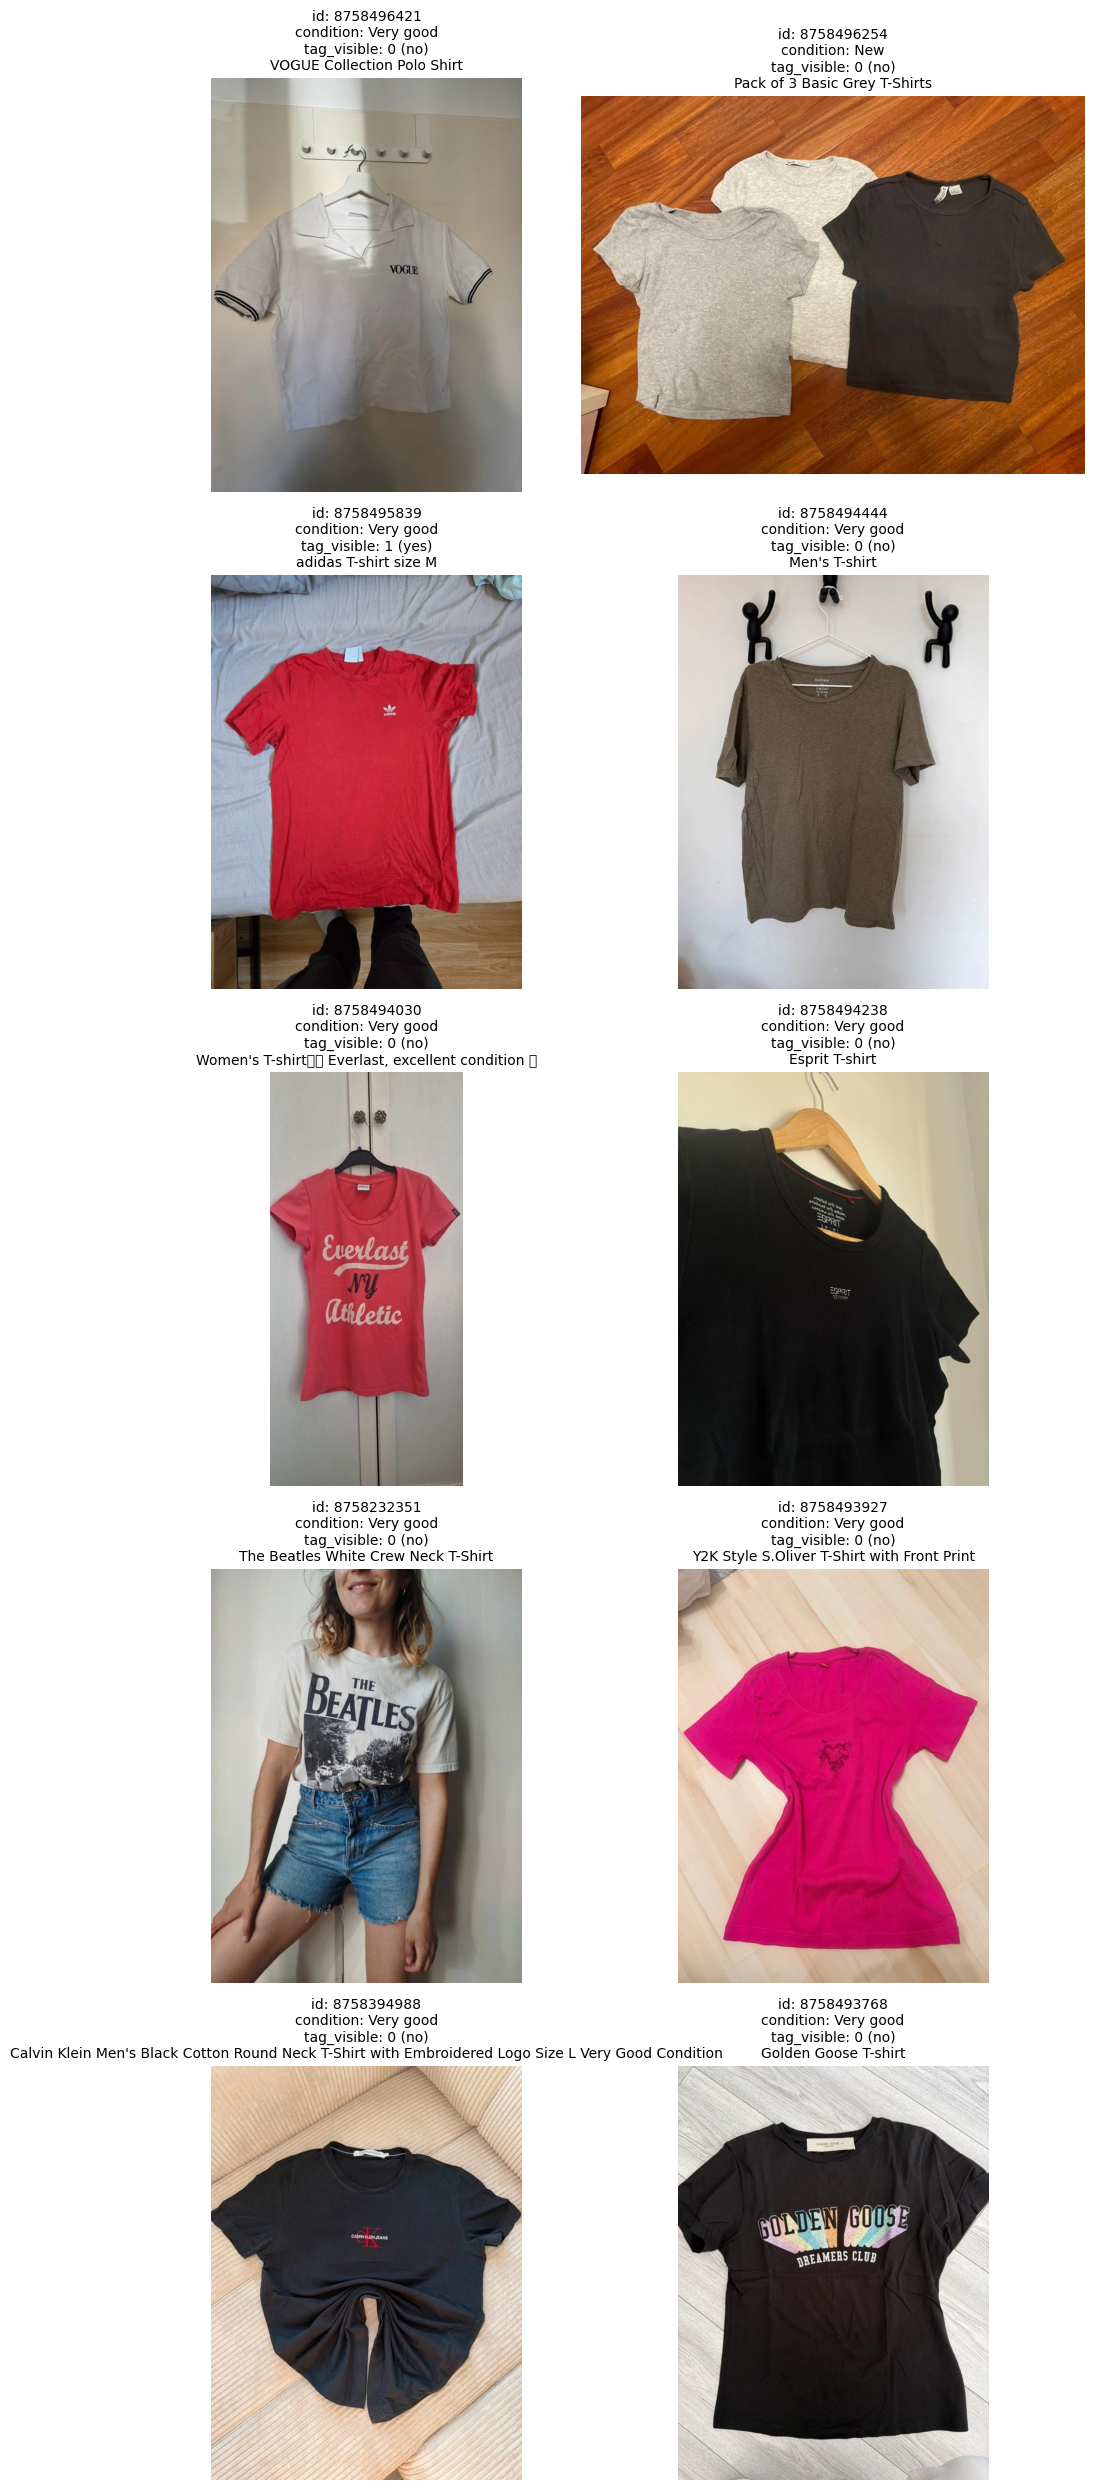

In [15]:
import pandas as pd
from PIL import Image
import io
import matplotlib.pyplot as plt

# Load smoke predictions
smoke = pd.read_parquet("/content/tag_visible_smoke.parquet")

# Load source data
vinted = pd.read_parquet("data/vinted_clothing_combined.parquet")
ka = pd.read_parquet("data/kleinanzeigen_clothing_combined.parquet")
df = pd.concat([vinted, ka], ignore_index=True)

# Join condition + image onto smoke rows
view = smoke.merge(
    df[["platform", "id", "condition_en", "title_en", "image"]],
    on=["platform", "id"],
    how="left",
)

def decode_image(cell):
    if isinstance(cell, dict) and cell.get("bytes") is not None:
        return Image.open(io.BytesIO(cell["bytes"])).convert("RGB")
    if isinstance(cell, dict) and cell.get("path"):
        return Image.open(cell["path"]).convert("RGB")
    if isinstance(cell, (bytes, bytearray)):
        return Image.open(io.BytesIO(cell)).convert("RGB")
    return cell

# Display images with prediction + condition
n = len(view)
cols = 2
rows = (n + cols - 1) // cols

plt.figure(figsize=(10, rows * 5))

for i, row in view.iterrows():
    img = decode_image(row["image"])

    ax = plt.subplot(rows, cols, i + 1)
    ax.imshow(img)
    ax.axis("off")

    ax.set_title(
        f"id: {row['id']}\n"
        f"condition: {row['condition_en']}\n"
        f"tag_visible: {row['tag_visible']} ({row['raw_response']})\n"
        f"{row.get('title_en', '')}",
        fontsize=10,
    )

plt.tight_layout()
plt.show()


In [16]:
import pandas as pd
from pathlib import Path

# Load full data
vinted = pd.read_parquet("data/vinted_clothing_combined.parquet")
ka = pd.read_parquet("data/kleinanzeigen_clothing_combined.parquet")
df = pd.concat([vinted, ka], ignore_index=True)

# Filter New with tags
nwt = df[df["condition_en"].eq("New with tags")].copy()

print("New with tags rows:", len(nwt))
print(nwt[["platform", "id", "condition_en", "title_en"]].head(10).to_string())

# Save small temporary parquets.
# Put the 5 target rows into vinted-path, and an empty same-schema frame into ka-path.
Path("/content/model3_nwt_test").mkdir(exist_ok=True)
nwt.head(5).to_parquet("/content/model3_nwt_test/vinted_nwt_5.parquet", index=False)
df.head(0).to_parquet("/content/model3_nwt_test/ka_empty.parquet", index=False)


New with tags rows: 905
    platform          id   condition_en                                                            title_en
28    vinted  8758480351  New with tags                                                Blue Striped T-Shirt
39    vinted  8758464472  New with tags                           T-Shirt by Mandala made of Organic Cotton
55    vinted  8758452887  New with tags                                               The Lion King T-Shirt
62    vinted  8758443372  New with tags    Primark Ratatouille Oversize Sleep Shirt/T-Shirt M/38/L/40/XL/42
125   vinted  8758558095  New with tags                                                Women's Barrel Jeans
136   vinted  8758526687  New with tags                      7 for all Mankind Modern Dojo Tailorless Jeans
164   vinted  8758525487  New with tags              Levi's 602 Orange Tab Slim Fits '76 W26 L34 IT40 Denim
168   vinted  8758523477  New with tags                                                      Folyrose jeans
182 

In [17]:
!python models/run_tag_detector.py \
  --model-id Qwen/Qwen3-VL-4B-Instruct \
  --adapter-id Rengo33/qwen3vl4b-resell-adapter \
  --load-in-4bit \
  --vinted-path /content/model3_nwt_test/vinted_nwt_5.parquet \
  --ka-path /content/model3_nwt_test/ka_empty.parquet \
  --output /content/tag_visible_nwt_5.parquet \
  --batch-size 1

Loading weights: 100% 713/713 [00:34<00:00, 20.72it/s]
Detecting visible tags: 100% 5/5 [01:08<00:00, 13.76s/it]
Saved tag-visible features: /content/tag_visible_nwt_5.parquet  rows=5
Parsed value counts:
tag_visible
1    4
0    1


In [18]:
pd.read_parquet("/content/tag_visible_nwt_5.parquet")

,platform,id,split,tag_visible,raw_response
0,vinted,8758480351,val,1,yes
1,vinted,8758464472,val,1,yes
2,vinted,8758452887,train,0,no
3,vinted,8758443372,train,1,yes
4,vinted,8758558095,train,1,yes


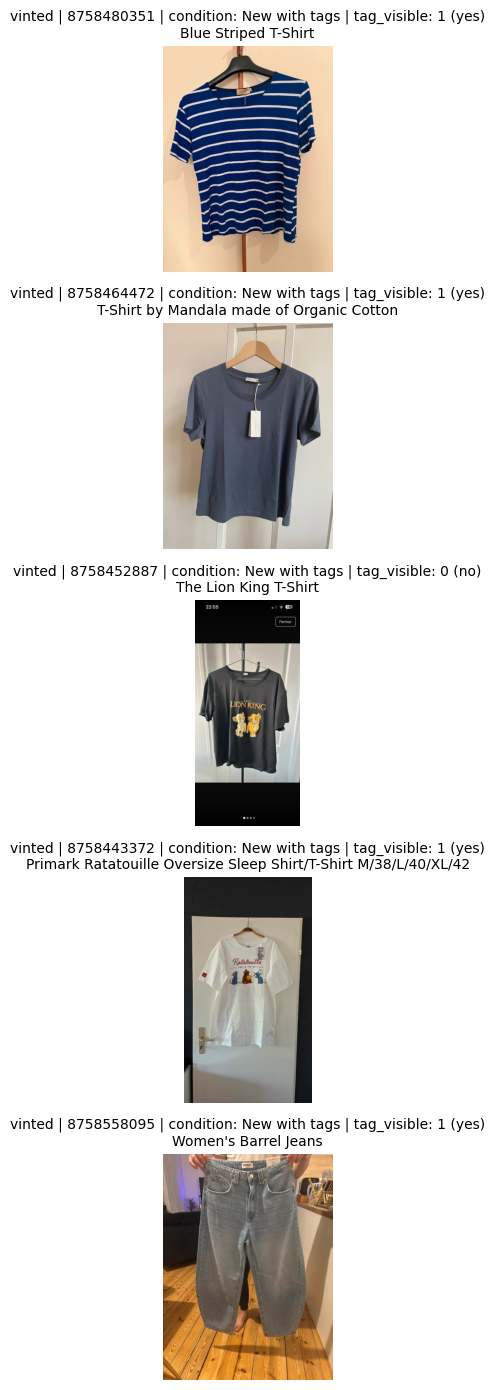

In [19]:
import io
from PIL import Image
import matplotlib.pyplot as plt

pred = pd.read_parquet("/content/tag_visible_nwt_5.parquet")
src = pd.read_parquet("/content/model3_nwt_test/vinted_nwt_5.parquet")

view = pred.merge(
    src[["platform", "id", "condition_en", "title_en", "image"]],
    on=["platform", "id"],
    how="left",
)

def decode_image(cell):
    if isinstance(cell, dict) and cell.get("bytes") is not None:
        return Image.open(io.BytesIO(cell["bytes"])).convert("RGB")
    if isinstance(cell, dict) and cell.get("path"):
        return Image.open(cell["path"]).convert("RGB")
    if isinstance(cell, (bytes, bytearray)):
        return Image.open(io.BytesIO(cell)).convert("RGB")
    return cell

plt.figure(figsize=(12, 14))

for i, row in view.iterrows():
    ax = plt.subplot(len(view), 1, i + 1)
    ax.imshow(decode_image(row["image"]))
    ax.axis("off")
    ax.set_title(
        f"{row['platform']} | {row['id']} | condition: {row['condition_en']} | "
        f"tag_visible: {row['tag_visible']} ({row['raw_response']})\n"
        f"{row['title_en']}",
        fontsize=10,
    )

plt.tight_layout()
plt.show()

If `tag_visible` is mostly `0` or `1` and `raw_response` is mostly `yes` or `no`, run the full dataset below.

## 9. Run Full Dataset

In [20]:
!python models/run_tag_detector.py \
  --model-id Qwen/Qwen3-VL-4B-Instruct \
  --adapter-id Rengo33/qwen3vl4b-resell-adapter \
  --load-in-4bit \
  --output data/features/tag_visible_combined.parquet \
  --batch-size 1

Loading weights: 100% 713/713 [00:34<00:00, 20.60it/s]
Detecting visible tags:   1% 100/8711 [25:12<37:05:47, 15.51s/it]^C


**Note: In Colab (free) this takes >40h to run. This is not important for now, try to rerun on runpod in the end"

## 10. Validate And Save Output

In [21]:
out = pd.read_parquet('data/features/tag_visible_combined.parquet')
print(out.shape)
print(out['tag_visible'].value_counts(dropna=False))
print('duplicates:', out.duplicated(['platform', 'id']).sum())
print(out.head().to_string())

# Keep a copy in Drive so it survives Colab runtime reset.
!cp data/features/tag_visible_combined.parquet "{DATA_SOURCE_DIR}/tag_visible_combined.parquet"
print('Copied to:', DATA_SOURCE_DIR + '/tag_visible_combined.parquet')

FileNotFoundError: [Errno 2] No such file or directory: 'data/features/tag_visible_combined.parquet'

## 11. Optional Download To Local Machine

In [ ]:
from google.colab import files
files.download('data/features/tag_visible_combined.parquet')